##**1) Data Loading & Cleaning**

In [100]:
!pip install openpyxl==3.0.9 -y


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -y


In [101]:
import numpy as np
import pandas as pd

**i. Load the IPL auction dataset using Pandas.**


Load and clean the 'Dataset.csv' datasets, merge them, and save the cleaned data.

In [102]:
df = pd.read_csv('Dataset.csv')


**ii. Display dataset shape and first 5 rows.**

In [103]:
display(df.head())

,Unnamed: 0,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
0,0,Shivam Mavi,4000000,BOWLER,6.0,720.0,KKR,Gujarat Titans
1,1,Joshua Little,5000000,BOWLER,4.4,528.0,NaN,Gujarat Titans
2,2,Kane Williamson,20000000,BATSMAN,2.0,240.0,SRH,Gujarat Titans
3,3,K.S. Bharat,2000000,WICKETKEEPER,1.2,144.0,DC,Gujarat Titans
4,4,Mohit Sharma,5000000,BOWLER,0.5,60.0,NaN,Gujarat Titans


**iii. Remove unnecessary columns (e.g., "Unnamed: 0").**

In [104]:
df = df.drop('Unnamed: 0', axis=1)

**iv. Check and handle missing values if any.**

In [105]:
missing_values = df.isnull().sum()
print(missing_values)

Player's List        0
Base Price           0
TYPE                 0
COST IN ₹ (CR.)    325
Cost IN $ (000)    325
2022 Squad         338
Team                 0
dtype: int64


In [106]:
cleaned_df = df.dropna()
print(cleaned_df)
display(cleaned_df.head())
cleaned_df.to_csv('cleaned_dataset.csv', index=False)

         Player's List Base Price          TYPE  COST IN ₹ (CR.)  \
0          Shivam Mavi    4000000        BOWLER              6.0   
2      Kane Williamson   20000000       BATSMAN              2.0   
3          K.S. Bharat    2000000  WICKETKEEPER              1.2   
5          Odean Smith    5000000   ALL-ROUNDER              0.5   
7        Rahul Tewatia   Retained   ALL-ROUNDER              0.0   
..                 ...        ...           ...              ...   
238        Abdul Samad   Retained       BATSMAN              0.0   
239    Abhishek Sharma   Retained   ALL-ROUNDER              0.0   
240      Aiden Markram   Retained       BATSMAN              0.0   
241  Bhuvneshwar Kumar   Retained        BOWLER              0.0   
242     Glenn Phillips   Retained  WICKETKEEPER              0.0   

     Cost IN $ (000) 2022 Squad                 Team  
0              720.0        KKR       Gujarat Titans  
2              240.0        SRH       Gujarat Titans  
3              144

,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
0,Shivam Mavi,4000000,BOWLER,6.0,720.0,KKR,Gujarat Titans
2,Kane Williamson,20000000,BATSMAN,2.0,240.0,SRH,Gujarat Titans
3,K.S. Bharat,2000000,WICKETKEEPER,1.2,144.0,DC,Gujarat Titans
5,Odean Smith,5000000,ALL-ROUNDER,0.5,60.0,PBKS,Gujarat Titans
7,Rahul Tewatia,Retained,ALL-ROUNDER,0.0,0.0,GT,Gujarat Titans


In [108]:
from google.colab import files
files.download('cleaned_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##EDA report and actions

I'll import the pandas and numpy library, load the  CSV files into dataframes and perform the EDA to understand the data and take actions to make this data usefull. Remove the unnecessary columns and handle the missing values

##**2) Costliest & Cheapest Players**

**i. Identify top 3 most expensive
players based on COST IN ₹ (CR.).**

In [109]:
df = pd.read_csv('cleaned_dataset.csv')
df_sorted = df.sort_values(by='COST IN ₹ (CR.)', ascending=False)
top_3_expensive = df_sorted.head(3)
display(top_3_expensive)

,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
96,Nicholas Pooran,20000000,WICKETKEEPER,16.00,1920.0,SRH,Lucknow Super Giants
170,Mayank Agarwal,10000000,BATSMAN,8.25,990.0,PBKS,Sunrisers Hyderabad
0,Shivam Mavi,4000000,BOWLER,6.00,720.0,KKR,Gujarat Titans


**ii. Identify top 5 cheapest players
and mention:**

In [110]:
df_sorted = df.sort_values(by='COST IN ₹ (CR.)', ascending=True)
top_5_cheapest = df_sorted.head(5)
display(top_5_cheapest)

,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
7,R. Sai Kishore,Retained,BOWLER,0.0,0.0,GT,Gujarat Titans
6,Rashid Khan,Retained,BOWLER,0.0,0.0,GT,Gujarat Titans
5,Pradeep Sangwan,Retained,ALL-ROUNDER,0.0,0.0,GT,Gujarat Titans
4,Rahul Tewatia,Retained,ALL-ROUNDER,0.0,0.0,GT,Gujarat Titans
11,Vijay Shankar,Retained,ALL-ROUNDER,0.0,0.0,GT,Gujarat Titans


##**SUMMARY**

After the cleaning of the dataset, the next task is to identify the top 3 most expensive player which are  Nicholas Pooran,Mayank Agarwal, and Shivam Mavi and the most cheapest player are are finded

##**3) Team-wise Spending Analysis**

In [111]:
df = pd.read_csv('cleaned_dataset.csv')
total_money_spent = df.groupby('Team')['COST IN ₹ (CR.)'].sum()
display(total_money_spent)

,COST IN ₹ (CR.)
Team,
Chennai Super Kings,0.70
Delhi Capitals,2.40
Gujarat Titans,9.70
Kolkata Knight Riders,2.00
Lucknow Super Giants,17.95
Mumbai Indians,0.20
Punjab Super Kings,0.00
Rajasthan Royals,6.25
Royal Challengers Banglore,0.00


**ii. Plot a bar chart showing team-wise total spending.**

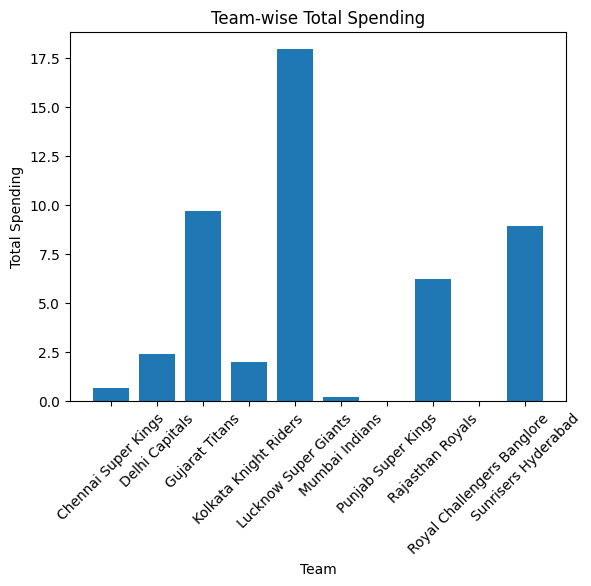

In [112]:
import matplotlib.pyplot as plt
plt.bar(total_money_spent.index, total_money_spent.values)
plt.xlabel('Team')
plt.ylabel('Total Spending')
plt.title('Team-wise Total Spending')
plt.xticks(rotation=45)
plt.show()


**iii. Mention the highest and lowest spending team.**

In [113]:
highest_spending_team = total_money_spent.idxmax()
lowest_spending_team = total_money_spent.idxmin()

print("Highest spending team : "+ highest_spending_team)
print("Lowest spending team : "+ lowest_spending_team)

Highest spending team : Lucknow Super Giants
Lowest spending team : Punjab Super Kings


##**SUMMARY**

In this part we will find out total money spend by the each team and plot the bar chart of the total spending of the teams and find the lowest and highest spending team

##**4) Franchise-wise Player Type Spending**

In [115]:

batsman_spending = df[df['TYPE'] == 'Batsman']['COST IN ₹ (CR.)'].sum()
bowler_spending = df[df['TYPE'] == 'Bowler']['COST IN ₹ (CR.)'].sum()
all_rounder_spending = df[df['TYPE'] == 'All-Rounder']['COST IN ₹ (CR.)'].sum()
wicketkeeper_spending = df[df['TYPE'] == 'Wicketkeeper']['COST IN ₹ (CR.)'].sum()
print("Total spending on Batsmen:",batsman_spending )
print("Total spending on Bowlers:", bowler_spending)
print("Total spending on All-rounders:", all_rounder_spending)
print("Total spending on Wicketkeepers:", wicketkeeper_spending)



Total spending on Batsmen: 0.0
Total spending on Bowlers: 0.0
Total spending on All-rounders: 0.0
Total spending on Wicketkeepers: 0.0


In [96]:
df.columns


Index(['Player's List', 'Base Price', 'TYPE', 'COST IN ₹ (CR.)',
       'Cost IN $ (000)', '2022 Squad', 'Team'],
      dtype='object')

##**5) Unsold Players Analysis**

**i. Find total number of unsold players.**

In [97]:
player_types = df['TYPE'].value_counts()
print("Total number of unsold players:", player_types.sum())
print("Type of players mostly unsold:", player_types)


Total number of unsold players: 185
Type of players mostly unsold: TYPE
ALL-ROUNDER     65
BOWLER          64
BATSMAN         35
WICKETKEEPER    21
Name: count, dtype: int64


**ii. Analyze which type of players (Batsman, Bowler, etc.) were mostly unsold.**

In [98]:
player_types = df['TYPE'].value_counts()
most_unsold_type = player_types.idxmax()
print("Type of players mostly unsold:", most_unsold_type)


Type of players mostly unsold: ALL-ROUNDER


##**SUMMARY**

After the cleaning of the dataset, the next task is to identify the top 3 most expensive player which are Nicholas Pooran, Mayank Agarwal, and Shivam Mavi and the most cheapest player are are finded.

After that we will find out total money spend by the each team and plot the bar chart of the total spending of the teams and find the lowest and highest spending team.

In the last we have check the total unsold players and the type of players that are unsold

##**6) Machine Learning – Team Prediction**

**Build a classification model to predict which team buys a player, using:
i. Features (example):
• Base Price
• Player Type
• 2022 Squad**

In [99]:

df = pd.read_csv('cleaned_dataset.csv')
team_mapping =


SyntaxError: invalid syntax (ipython-input-4231887122.py, line 7)